# Clustering Synthetic 2D Data: K-Means vs Fuzzy K-Means for clustering users based on behaviour

---

## Pipeline at a Glance

```
Synthetic 2D Data (make_blobs)
    │
    ▼
K-Means        → hard labels (0 .. K-1)
    │
Fuzzy K-Means  → soft memberships u_ik  (each column/point sums to 1)
    │
Comparison with some visualizations to support the use of Fuzzy K-Means over crisp K-means.


## 1. Imports

In [142]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.spatial.distance import cdist
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
import warnings

warnings.filterwarnings('ignore')
np.random.seed(42)

# Consistent colour palette
PALETTE   = ['#E07B54', '#5B8DB8', '#6AAB7A', '#9B59B6', '#F4D03F', '#E74C3C', '#1ABC9C', '#E67E22', '#2ECC71', '#3498DB']
C_NAMES   = [f'Cluster {chr(65+i)}' for i in range(10)]
THEME_CLR = {i: PALETTE[i] for i in range(10)}

plt.rcParams.update({
    'figure.facecolor': '#FAFAFA',
    'axes.facecolor':   '#FAFAFA',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.family':      'Garamond',
})
print("Libraries loaded!")


Libraries loaded!


___

## 2. Dataset: CC usage 

The idea is to analyze the behaviour of Credit Card holders from a dataset [https://raw.githubusercontent.com/daniel-bss/credit-card-clustering/main/CC%20GENERAL.csv].

The objective is to understand what kind of user we are dealing with depending on how often the client loads up their CC. 
To do that, we construct 3 different kind of user based on the balance on the account and the number of purchases done via the card.
K-Means and Fuzzy C-Means are all being compared against the feature we crafted, to see how well they cluster the clients.


In [143]:
CSV_PATH = 'CC data.csv'

raw = pd.read_csv(CSV_PATH, index_col = 'CUST_ID')

raw = raw.dropna(subset=['PURCHASES', 'CASH_ADVANCE'])
raw.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
CUST_ID,,,,,,,,,,,,,,,,,
C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [144]:
def assign_behavior(row):
    p = row['PURCHASES']
    ca = row['CASH_ADVANCE']

    if ca > 1.5 * p and ca > 4000:
        return 'Heavy Borrower'
    elif p > 1.5 * ca and p > 4000:
        return 'Abhors Borrowing'
    elif  p < 1000 and ca < 1000:
        return 'Dormant'
    elif 0.5 <= ca / (p + 1) and max(p, ca) > 3000:
        return 'Emergencial Borrower'
    else:
        return 'Typical Client'

4 types of client:
- Heavy Borrower, he who borrows his way through life, has both high cash advance as well as total purchases.
- Emergencial borrowers, they must borrow 'cuz of emergencies. High Cash Advance over Purchase ratio
- He who abhors borrowing, his cash advance is almost none regardless of his purchases.
- Typical client, small cash advance when compared to purchases or balance.

In [145]:
raw['True_Behavior'] = raw.apply(assign_behavior, axis=1)
print(f"Loaded {len(raw)} rows. Raw behavior distribution:\n{raw['True_Behavior'].value_counts().to_string()}")

Loaded 8950 rows. Raw behavior distribution:
True_Behavior
Dormant                 4557
Typical Client          3051
Heavy Borrower           579
Abhors Borrowing         416
Emergencial Borrower     347


In [146]:
N = 4500
target_names = ['Abhors Borrowing', 'Heavy Borrower', 'Typical Client', 'Dormant', 'Emergencial Borrower']

label_mapping = {
    'Abhors Borrowing': 0,
    'Heavy Borrower': 1,
    'Typical Client': 2,
    'Dormant':3,
    'Emergencial Borrower':4
}

sample = raw
#sample = raw.sample(n = N)

In [147]:
y_true = raw['True_Behavior'].map(label_mapping).to_numpy()
X_raw = sample[['PURCHASES', 'CASH_ADVANCE']].to_numpy()
feature_names = ['Purchases', 'Cash Advance']

N_CENTERS = len(target_names)

In [148]:
scaler = StandardScaler()
X = (X_raw)

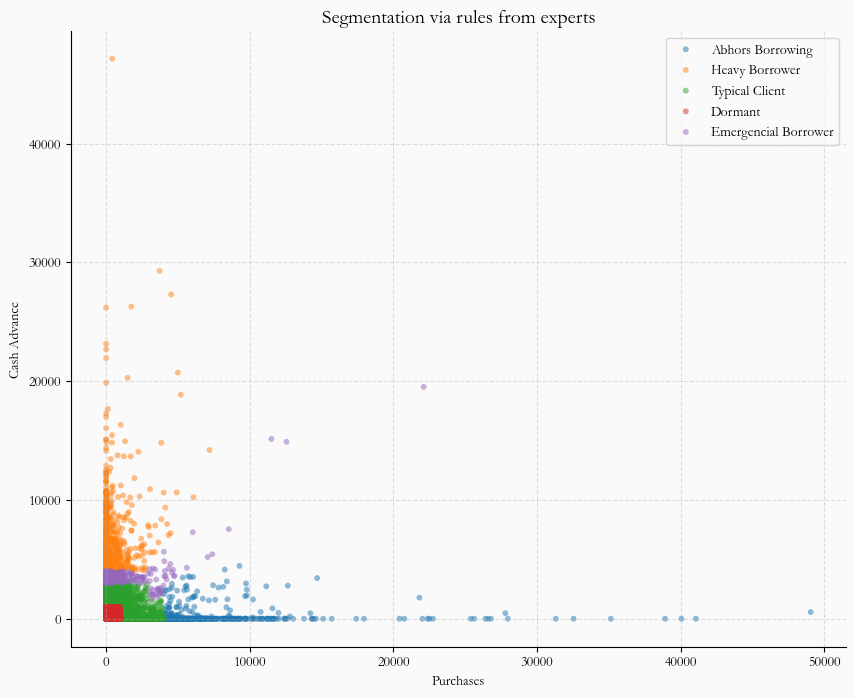

X shape: (8950, 2)  |  True number of archetypes: 5
Features used: ['Purchases', 'Cash Advance']


In [149]:
plt.figure(figsize=(10, 8))
for cls in range(N_CENTERS):
    mask = y_true == cls
    plt.scatter(X[mask, 0], X[mask, 1], s=18, alpha=0.5, edgecolor='none',
                label=target_names[cls])
plt.title('Segmentation via rules from experts', fontsize=14)
plt.xlabel(f'{feature_names[0]}')
plt.ylabel(f'{feature_names[1]}')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.show()

print(f"X shape: {X.shape}  |  True number of archetypes: {N_CENTERS}")
print(f"Features used: {feature_names}")

___

## 3. Crisp K-Means

**Objective**: minimise the within-cluster sum of squared distances (WCSS):

$$J_{KM} = \sum_{k=1}^{K} \sum_{i : z_i = k} \|\mathbf{x}_i - \mathbf{v}_k\|^2$$

**Algorithm (alternating optimisation):**
1. Randomly initialize $K$ centroids $\{v_k\}$.
2. **Assignment step**: assign each point to its nearest centroid: $z_i = \arg\min_k \|x_i - v_k\|$.
3. **Update step**: move each centroid to the mean of its assigned points.
4. Repeat until centroids no longer move or a completition criterion has been met (e.g # of runs).


In [150]:
def kmeans(X: np.ndarray, k: int, max_iter: int = 300, tol: float = 1e-6, seed: int = 42):
    """
    Classic K-Means via alternating optimisation.
    Returns: labels, centroids, inertia (WCSS)
    """
    np.random.seed(seed)
    idx = np.random.choice(X.shape[0], size=k, replace=False)
    centroids = X[idx].copy()

    for _ in range(max_iter):
        dists  = cdist(X, centroids)          # (n, k) pairwise Euclidean distances
        labels = dists.argmin(axis=1)         # hard assignment

        new_centroids = np.array([
            X[labels == c].mean(axis=0) if (labels == c).any() else centroids[c]
            for c in range(k)
        ])
        if np.linalg.norm(new_centroids - centroids) < tol:
            break
        centroids = new_centroids

    inertia = sum(
        np.linalg.norm(X[labels == c] - centroids[c]) ** 2
        for c in range(k) if (labels == c).any()
    )
    return labels, centroids, inertia


In [151]:
K = N_CENTERS 
km_labels, km_centroids, km_inertia = kmeans(X, K)

print(f"K-Means inertia (WCSS): {km_inertia:.4f}")
print()
print("Cluster sizes:")
for c in range(K):
    mask = km_labels == c
    print(f"  Cluster {c}: {mask.sum()} points")


K-Means inertia (WCSS): 19047681940.9782

Cluster sizes:
  Cluster 0: 1262 points
  Cluster 1: 176 points
  Cluster 2: 6836 points
  Cluster 3: 652 points
  Cluster 4: 24 points


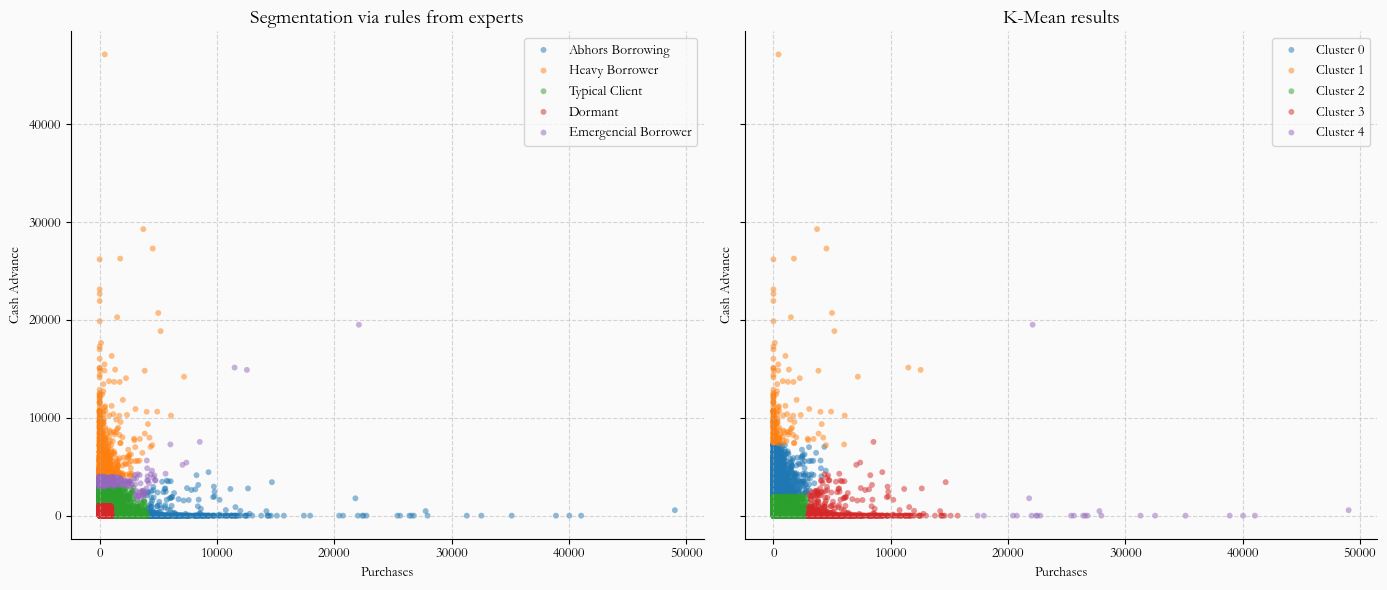

In [152]:
# Compare K-Means assignment against the expert defined 'truth'
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

# Panel A: ground-truth gender
for cls in range(N_CENTERS):
    mask = y_true == cls
    axes[0].scatter(X[mask, 0], X[mask, 1], s=18, edgecolor='none', alpha=0.5,
                     label=target_names[cls])
axes[0].set_title('Segmentation via rules from experts', fontsize=14)
axes[0].set_xlabel('Purchases')
axes[0].set_ylabel('Cash Advance')
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend()

# Panel B: K-Means hard assignment
for cls in range(N_CENTERS):
    mask = km_labels == cls
    axes[1].scatter(X[mask, 0], X[mask, 1], s=18, edgecolor='none', alpha=0.5,
                     label=f'Cluster {cls}')
axes[1].set_title('K-Mean results', fontsize=14)
axes[1].set_xlabel('Purchases')
axes[1].set_ylabel('Cash Advance')
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend()

plt.tight_layout()
plt.show()

___

## 4. Fuzzy K-Means

**Objective**: minimise the fuzzy weighted WCSS:

$$J_{FCM} = \sum_{k=1}^{K} \sum_{i=1}^{N} u_{ik}^m \|\mathbf{x}_i - \mathbf{v}_k\|^2$$

where $u_{ik} \in [0, 1]$ is the **membership** of point $i$ in cluster $k$, and $m > 1$ is
the **fuzzifier** (typically $m=2$). $m = 1$ lands us back into Crisp K-Means.

**Constraints:**
$$\sum_{k=1}^{K} u_{ik} = 1 \quad \forall i \qquad \text{(each point's memberships sum to 1)}$$

**Update rules (closed form):**
$$u_{ik} = \frac{1}{\displaystyle\sum_{j=1}^{K} \left(\frac{\|x_i - v_k\|}{\|x_i - v_j\|}\right)^{\frac{2}{m-1}}}
\qquad
v_k = \frac{\sum_i u_{ik}^m\, x_i}{\sum_i u_{ik}^m}$$

**What FCM adds over K-Means:**
- A point sitting in the overlap between two blobs gets partial membership
  in both clusters rather than being forced into only one of the 2.
- The membership matrix $U$ quantifies *confidence*: high $u_{ik}$ leads to a clear assignment, similar values among several cluster signal ambiguity in the allocation to a specific cluster.


| Step | K-Means | Fuzzy C-Means | 
|------|---------|---------------|
| Initialise | pick random **centroids** | initialise random **U** (membership matrix) |
| Centroid update | **unweighted mean** of hard-assigned members | **fuzzy-weighted mean** $v_k = \frac{\sum_i u_{ik}^m x_i}{\sum_i u_{ik}^m}$ |
| Assignment | hard `argmin` → one label per point | soft rule $u_{ik} = \frac{1}{\sum_j(d_{ik}/d_{ij})^{2/(m-1)}}$ → one row per point |


**Limitation:** The constraint $\sum_k u_{ik} = 1$ means that even a true outlier must have memberships summing to 1, artificially inflating its
apparent relevance to clusters. 

This can be handled by running Possibilistic Clustering which removes this condition, or by making use of one of the many extensions of these algorithms (such the one which implements an outlier-dedicated cluster).


In [153]:
def fuzzy_cmeans(X: np.ndarray, k: int, m: float = 2,
                 max_iter: int = 300, tol: float = 1e-6, seed: int = 42):
    """
    Fuzzy C-Means, built from kmeans() with minimal changes.

    Changes w.r.t kmeans()
    -------------------
    1. Initialise U (membership matrix) instead of random centroids.
    2. Centroid update: fuzzy-weighted mean  instead of an unweighted mean.
    3. Assignment    : soft membership rule  instead of an hard argmin.
    -------------------

    Everything else is identical to kmeans().
    """
    n = X.shape[0]
    np.random.seed(seed)

    # CHANGE 1: initialise membership matrix U instead of centroids
    U = np.random.dirichlet(np.ones(k), size=n).T   # shape (k, n)
    centroids = np.zeros((k, X.shape[1]))            # computed from U in first iter

    for _ in range(max_iter):

        # CHANGE 2: fuzzy-weighted centroid update
        W = U ** m                                             # (k, n)  fuzzified weights
        centroids = (W @ X) / W.sum(axis=1, keepdims=True)   # (k, d)

        # distance matrix -- identical to kmeans
        dists = cdist(X, centroids)                           # (n, k)

        # CHANGE 3: soft membership update instead of hard argmin
        power = 2.0 / (m - 1)
        U_new = np.zeros((k, n))
        for i in range(n):
            d = dists[i]                                      # distances to all k centroids
            if np.any(d == 0):                               # point sits on a centroid
                U_new[:, i] = (d == 0).astype(float)
            else:
                ratios = (d[:, None] / d[None, :]) ** power  # (k, k)
                U_new[:, i] = 1.0 / ratios.sum(axis=1)

        # convergence check, same pattern as kmeans but applied to U instead of the centroids
        if np.linalg.norm(U_new - U) < tol:
            U = U_new
            break
        U = U_new

    labels = U.argmax(axis=0)
    fpc = (U ** 2).sum() / n   # Fuzzy Partition Coefficient
    return labels, centroids, U, fpc


With many points, printing the full membership matrix isn't feasible. Let's print the most confident and the most ambigous points (found via entropy) instead, so that we could actually get something readable.

In [154]:
fcm_labels, cntr_fcm, U_fcm, fpc = fuzzy_cmeans(X, K, 2)

print(f"Fuzzy Partition Coefficient (FPC): {fpc:.4f}")
print("  (1.0 = crisp partition, 1/K = maximally fuzzy)")
print()


fcm_entropy = -np.sum(U_fcm * np.log(U_fcm + 1e-10), axis=0)
most_confident = np.argsort(fcm_entropy)[:5]
most_ambiguous = np.argsort(fcm_entropy)[-5:]

print("Membership matrix U [rows=clusters], sample of 5 most-confident points:")
print(pd.DataFrame(np.round(U_fcm[:, most_confident], 3),
                    index=[f'Cluster {c}' for c in range(K)],
                    columns=[f'pt{i}' for i in most_confident]).to_string())
print()
print("Membership matrix U [rows=clusters], sample of 5 most-ambiguous points:")
print(pd.DataFrame(np.round(U_fcm[:, most_ambiguous], 3),
                    index=[f'Cluster {c}' for c in range(K)],
                    columns=[f'pt{i}' for i in most_ambiguous]).to_string())
print()
print(f"Column sums across all {len(X)} points (should all be ~1.0):",
      f"min={U_fcm.sum(axis=0).min():.4f}  max={U_fcm.sum(axis=0).max():.4f}")


Fuzzy Partition Coefficient (FPC): 0.7578
  (1.0 = crisp partition, 1/K = maximally fuzzy)

Membership matrix U [rows=clusters], sample of 5 most-confident points:
           pt8054  pt8876  pt2386  pt4670  pt342
Cluster 0     0.0     0.0     0.0     0.0    0.0
Cluster 1     0.0     0.0     0.0     0.0    0.0
Cluster 2     0.0     0.0     0.0     0.0    0.0
Cluster 3     1.0     1.0     1.0     1.0    1.0
Cluster 4     0.0     0.0     0.0     0.0    0.0

Membership matrix U [rows=clusters], sample of 5 most-ambiguous points:
           pt501  pt6258  pt5358  pt550  pt2159
Cluster 0  0.167   0.157   0.227  0.174   0.264
Cluster 1  0.195   0.270   0.178  0.196   0.179
Cluster 2  0.171   0.223   0.177  0.177   0.202
Cluster 3  0.172   0.151   0.157  0.178   0.179
Cluster 4  0.295   0.200   0.260  0.275   0.174

Column sums across all 8950 points (should all be ~1.0): min=1.0000  max=1.0000


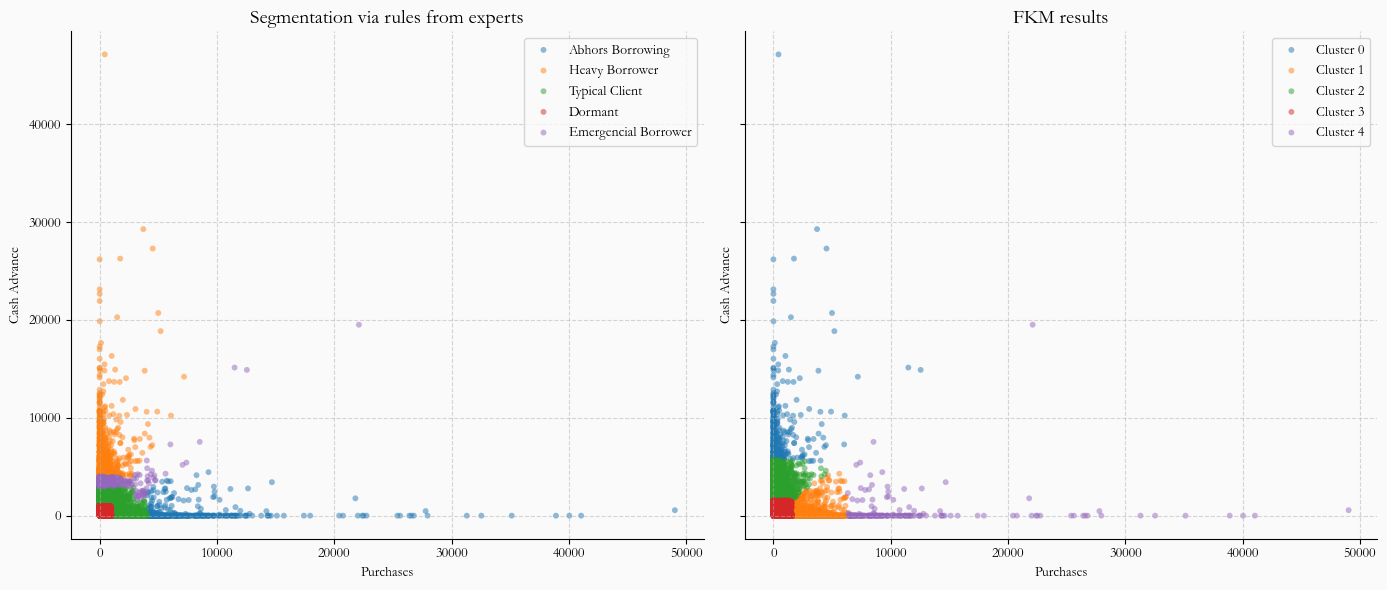

ARI (K-Means): 0.3828596617077792
NMI (K-Means): 0.4759289143821607
ARI (FKM):     0.5115102849852728
NMI (FKM):     0.5293542811060333


In [155]:
# Compare FK-Means assignment against the expert defined 'truth'
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

# Panel A: ground-truth gender
for cls in range(N_CENTERS):
    mask = y_true == cls
    axes[0].scatter(X[mask, 0], X[mask, 1], s=18, edgecolor='none', alpha=0.5,
                     label=target_names[cls])
axes[0].set_title('Segmentation via rules from experts', fontsize=14)
axes[0].set_xlabel('Purchases')
axes[0].set_ylabel('Cash Advance')
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend()

# Panel B: FK-Means hard assignment
for cls in range(N_CENTERS):
    mask = fcm_labels == cls
    axes[1].scatter(X[mask, 0], X[mask, 1], s=18, edgecolor='none', alpha=0.5,
                     label=f'Cluster {cls}')
axes[1].set_title('FKM results', fontsize=14)
axes[1].set_xlabel('Purchases')
axes[1].set_ylabel('Cash Advance')
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend()

plt.tight_layout()
plt.show()

print("ARI (K-Means):", adjusted_rand_score(y_true, km_labels))
print("NMI (K-Means):", normalized_mutual_info_score(y_true, km_labels))
print("ARI (FKM):    ", adjusted_rand_score(y_true, fcm_labels))
print("NMI (FKM):    ", normalized_mutual_info_score(y_true, fcm_labels))

___

## 5. Visualisation via 2D Plot


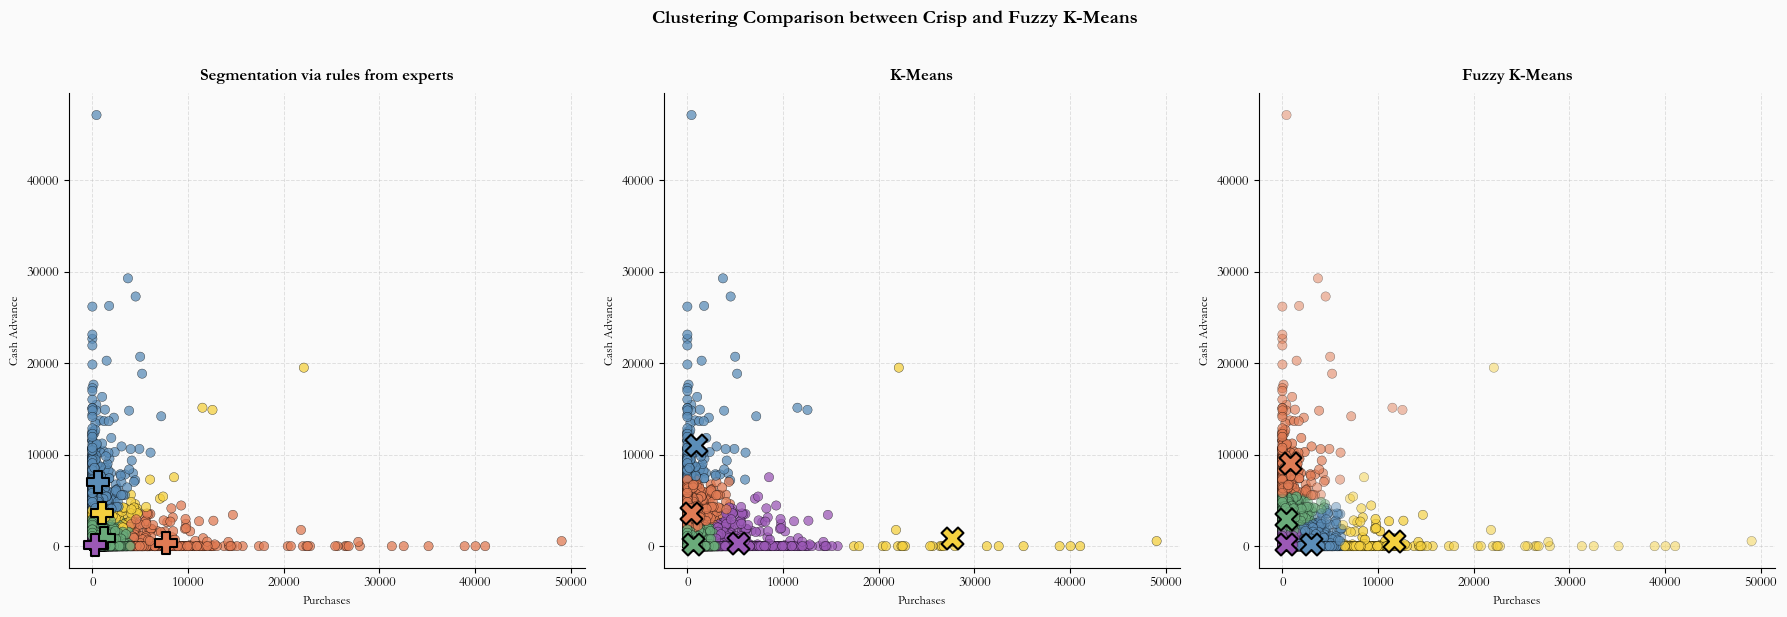

In [156]:
xs, ys = X[:, 0], X[:, 1]

algo_configs = [
    {"title": "Segmentation via rules from experts", "labels": y_true, "U": None, "is_truth": True},
    {"title": "K-Means", "labels": km_labels, "U": None, "is_truth": False},
    {"title": "Fuzzy K-Means", "labels": fcm_labels, "U": U_fcm, "is_truth": False}
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor='#FAFAFA')
title_features = "between Crisp and Fuzzy K-Means"
fig.suptitle(f"Clustering Comparison {title_features}", fontsize=14, fontweight='bold', y=1.02)

n = len(X)

for ax, cfg in zip(axes, algo_configs):
    ax.set_title(cfg["title"], fontsize=12, fontweight='bold', pad=10)
    ax.set_facecolor('#FAFAFA')
    ax.grid(True, linestyle='--', alpha=0.35, linewidth=0.7)

    labels = cfg["labels"]
    colours = [PALETTE[int(labels[i]) % len(PALETTE)] for i in range(n)]

    # Opacity mapping strategy
    if cfg.get("U") is not None:
        alphas = 0.3 + 0.6 * cfg["U"].max(axis=0)
    else:
        alphas = np.full(n, 0.75)

    # Render data points
    ax.scatter(xs, ys, c=colours, s=45, marker='o',
               alpha=alphas, edgecolors='k', linewidths=0.3, zorder=3)

    # Plot centers based on panel context
    if not cfg.get("is_truth"):
        for c_id in range(K):
            member_mask = (labels == c_id)
            if member_mask.any():
                cx = xs[member_mask].mean()
                cy = ys[member_mask].mean()
                ax.scatter(cx, cy, c=PALETTE[c_id % len(PALETTE)], s=250, marker='X',
                           edgecolors='black', linewidths=1.5, zorder=5)
    else:
        for c_id in range(K):
            member_mask = (y_true == c_id)
            if member_mask.any():
                cx = xs[member_mask].mean()
                cy = ys[member_mask].mean()
                ax.scatter(cx, cy, c=PALETTE[c_id % len(PALETTE)], s=250, marker='P',
                           edgecolors='black', linewidths=1.5, zorder=5)

    ax.set_xlabel(f"{feature_names[0]}", fontsize=9)
    ax.set_ylabel(f"{feature_names[1]}", fontsize=9)

plt.tight_layout()
plt.show()

One thing to note, by playing with the fuzzifier you can get Fuzzy K-means to both improve ora worsen the resulting clustering (m <= 3 is recommended here)

___

## 6. Comparisons and evaluation
We have seen the resulting clusters side by side but...how can we tell which one is more similar to the rules the expert set? 
Let's look at how the algorithms behaved in cases of high uncertainty: plot the points over the original assignment by rule and let's look as their summary statistics.


In [157]:
import numpy as np
from scipy.optimize import linear_sum_assignment

def align_clusters_to_experts(expert_labels, pred_labels, centroids):
    """
    Aligns algorithm labels to expert labels using a 1-to-1 mapping 
    based on maximum point overlap.
    """
    K = len(centroids)
    cost_matrix = np.zeros((K, K), dtype=int)
    
    # Count the overlaps between expert labels and predicted labels
    for exp, pred in zip(expert_labels, pred_labels):
        if exp < K and pred < K: 
            cost_matrix[int(exp), int(pred)] += 1
            
    # Use Hungarian algorithm to maximize overlap (minimize negative cost). Not that I really understood it even after looking it up lol
    expert_idx, pred_idx = linear_sum_assignment(-cost_matrix)
    
    # Create mapping
    mapping = {p: e for e, p in zip(expert_idx, pred_idx)}
    
    # Apply the mapping to labels
    aligned_labels = np.array([mapping[l] for l in pred_labels])
    
    # Apply the mapping to centroids
    aligned_centroids = np.zeros_like(centroids)
    for p_idx, e_idx in mapping.items():
        aligned_centroids[e_idx] = centroids[p_idx]
        
    return aligned_labels, aligned_centroids

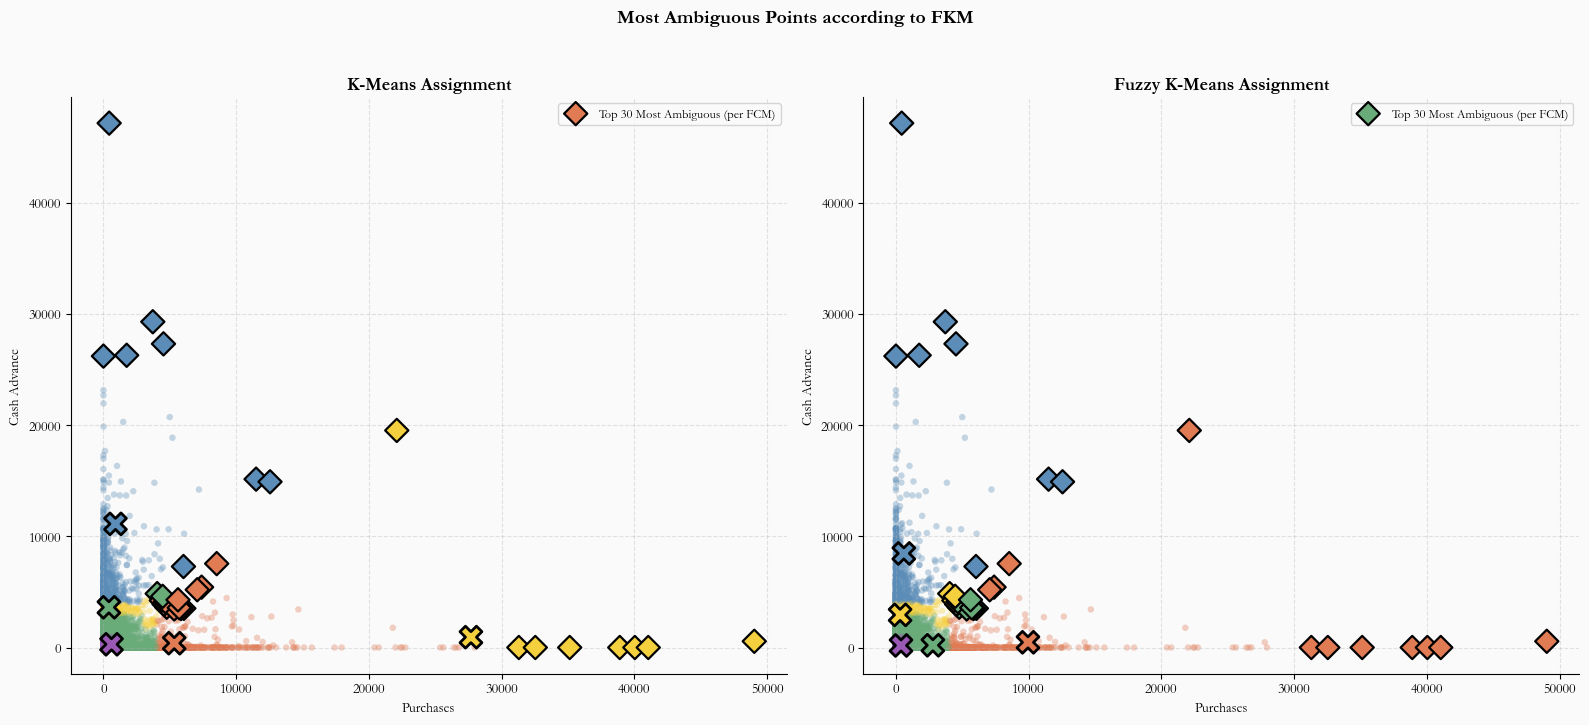

The 30 most ambiguous points (highest FKM entropy) are diamond-marked above.
Mean FKM entropy of these points: 1.565  (max possible = 1.609)


In [158]:
# Align labels to expert segments for semantic coloring
km_labels_aligned, km_centroids_aligned = align_clusters_to_experts(y_true, km_labels, km_centroids)
fcm_labels_aligned, cntr_fcm_aligned = align_clusters_to_experts(y_true, fcm_labels, cntr_fcm)

# Identify the most ambiguous points according to FKM 
fcm_entropy = -np.sum(U_fcm * np.log(U_fcm + 1e-10), axis=0)   
N_AMBIGUOUS = 30
ambiguous_idx = np.argsort(fcm_entropy)[-N_AMBIGUOUS:]          

fig, axes = plt.subplots(1, 2, figsize=(16, 7), facecolor='#FAFAFA')

# Use the ALIGNED labels and centroids here
panels = [
    ("K-Means Assignment", km_labels_aligned, km_centroids_aligned),
    ("Fuzzy K-Means Assignment", fcm_labels_aligned, cntr_fcm_aligned),
]

for ax, (title, labels, centroids) in zip(axes, panels):
    
    # 1. Background: Original distribution based on expert rules
    expert_bg_colours = [PALETTE[int(l) % len(PALETTE)] for l in y_true]
    ax.scatter(X[:, 0], X[:, 1], c=expert_bg_colours, s=22, alpha=0.35, edgecolor='none', zorder=1)

    # 2. Highlight: FKM-flagged ambiguous points, colored by THIS panel's ALIGNED algorithm
    amb_colours = [PALETTE[int(labels[i]) % len(PALETTE)] for i in ambiguous_idx]
    ax.scatter(X[ambiguous_idx, 0], X[ambiguous_idx, 1], c=amb_colours, s=140,
               edgecolor='black', linewidths=1.6, marker='D', zorder=5,
               label=f'Top {N_AMBIGUOUS} Most Ambiguous (per FCM)')

    # 3. Cluster centroids colored by their semantically ALIGNED clusters
    centroids = np.asarray(centroids)
    centroid_colours = [PALETTE[i % len(PALETTE)] for i in range(len(centroids))]
    
    ax.scatter(centroids[:, 0], centroids[:, 1], c=centroid_colours, s=250, 
               marker='X', edgecolor='black', linewidths=2, zorder=6)

    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel(f'{feature_names[0]}')
    ax.set_ylabel(f'{feature_names[1]}')
    ax.grid(True, linestyle='--', alpha=0.35)
    ax.legend(loc='upper right', fontsize=9)

fig.suptitle('Most Ambiguous Points according to FKM',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

print(f"The {N_AMBIGUOUS} most ambiguous points (highest FKM entropy) are diamond-marked above.")
print(f"Mean FKM entropy of these points: {fcm_entropy[ambiguous_idx].mean():.3f}  "
      f"(max possible = {np.log(len(centroids)):.3f})")

We will now move on to evaluating how close they are to the original "expert"-crafted segmentation, and from there pick the one that is closest.

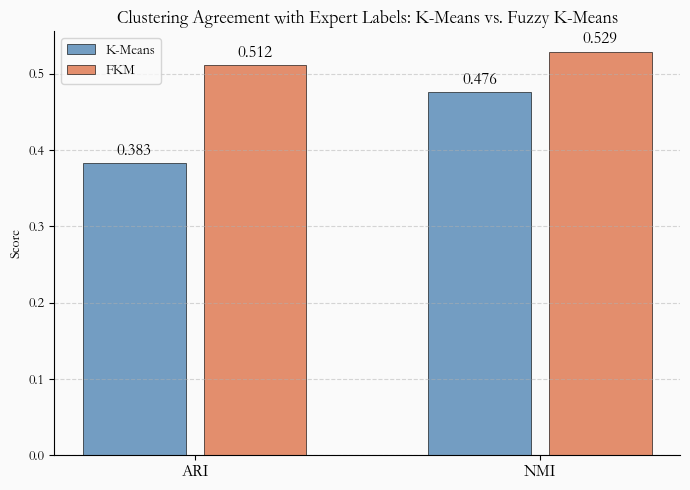

In [173]:
# Compute the four scores
scores = {
    'K-Means': {
        'ARI': adjusted_rand_score(y_true, km_labels),
        'NMI': normalized_mutual_info_score(y_true, km_labels),
    },
    'FKM': {
        'ARI': adjusted_rand_score(y_true, fcm_labels),
        'NMI': normalized_mutual_info_score(y_true, fcm_labels),
    },
}

metrics = ['ARI', 'NMI']
algorithms = list(scores.keys())
x = np.arange(len(metrics))
width = 0.35

colors = {'K-Means': '#5B8DB8', 'FKM': '#E07B54'}

fig, ax = plt.subplots(figsize=(7, 5))

for i, algo in enumerate(algorithms):
    values = [scores[algo][m] for m in metrics]
    offset = (i - 0.5) * width
    bars = ax.bar(x + offset, values, 0.85 * width, label=algo,
                   color=colors[algo], alpha=0.85, edgecolor='black', linewidth=0.5)
    ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=12)

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylabel('Score')
ax.set_title('Clustering Agreement with Expert Labels: K-Means vs. Fuzzy K-Means', fontsize=13)
ax.set_ylim(0, 1.05 * max(v for algo in scores.values() for v in algo.values()))
ax.grid(True, axis='y', linestyle='--', alpha=0.5)
ax.legend()

plt.tight_layout()
plt.show()

___

Legacy version, ignore

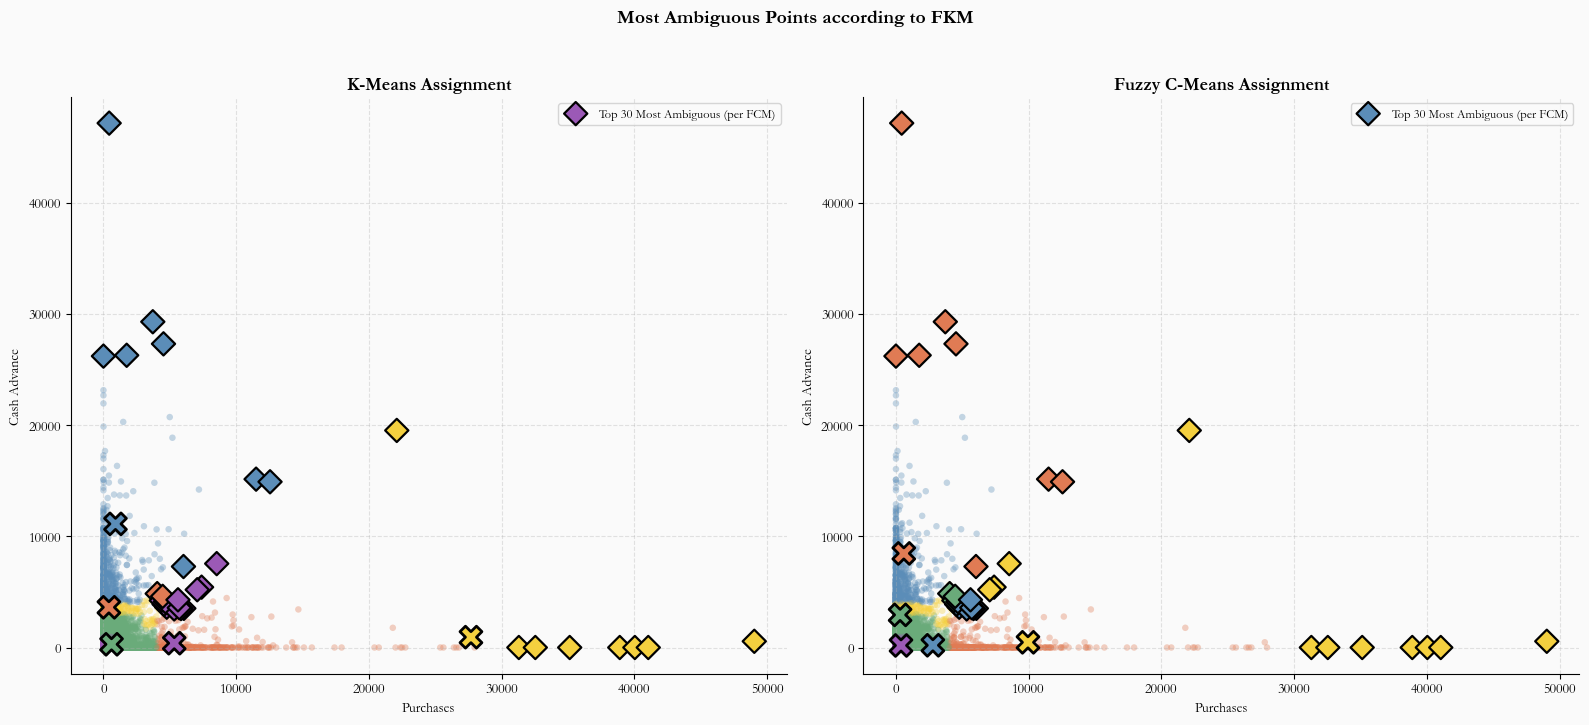

The 30 most ambiguous points (highest FCM entropy) are diamond-marked above.
Mean FCM entropy of these points: 1.565  (max possible = 1.609)


In [161]:

fcm_entropy = -np.sum(U_fcm * np.log(U_fcm + 1e-10), axis=0)   # 0 = fully confident, higher = torn between clusters
N_AMBIGUOUS = 30
ambiguous_idx = np.argsort(fcm_entropy)[-N_AMBIGUOUS:]          # indices of the N most uncertain points

fig, axes = plt.subplots(1, 2, figsize=(16, 7), facecolor='#FAFAFA')

panels = [
    ("K-Means Assignment", km_labels, km_centroids),
    ("Fuzzy C-Means Assignment", fcm_labels, cntr_fcm),
]

for ax, (title, labels, centroids) in zip(axes, panels):
    

    expert_bg_colours = [PALETTE[int(l) % len(PALETTE)] for l in y_true]
    ax.scatter(X[:, 0], X[:, 1], c=expert_bg_colours, s=22, alpha=0.35, edgecolor='none', zorder=1)

    amb_colours = [PALETTE[int(labels[i]) % len(PALETTE)] for i in ambiguous_idx]
    ax.scatter(X[ambiguous_idx, 0], X[ambiguous_idx, 1], c=amb_colours, s=140,
               edgecolor='black', linewidths=1.6, marker='D', zorder=5,
               label=f'Top {N_AMBIGUOUS} Most Ambiguous (per FCM)')

    centroids = np.asarray(centroids)
    centroid_colours = [PALETTE[i % len(PALETTE)] for i in range(len(centroids))]
    
    ax.scatter(centroids[:, 0], centroids[:, 1], c=centroid_colours, s=250, 
               marker='X', edgecolor='black', linewidths=2, zorder=6)

    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel(f'{feature_names[0]}')
    ax.set_ylabel(f'{feature_names[1]}')
    ax.grid(True, linestyle='--', alpha=0.35)
    ax.legend(loc='upper right', fontsize=9)

fig.suptitle('Most Ambiguous Points according to FKM',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

print(f"The {N_AMBIGUOUS} most ambiguous points (highest FCM entropy) are diamond-marked above.")
print(f"Mean FCM entropy of these points: {fcm_entropy[ambiguous_idx].mean():.3f}  "
      f"(max possible = {np.log(K):.3f})")